# Simulate Populations with Asexual Reproduction
## Part 1

In the previous section, we explored the characteristics of a population of protocells, which can spontaneusly assemble from molecules under the right conditions.

Let's jump forward a bit and assume that one of our protocells managed to carry information (DNA) about how it is assembled within its cell walls. Let's further assume that this organism is able to reproduce [asexually][1] (it does not need a partner) using its DNA and it passes the DNA on to its offspring. This is the primary means of reproduction for [single-celled (unicellular) organisms][2] such as [archae][3] and [bacteria][4].

### Properties of Unicellurar Organisms

Just like our protocells, these unicellular organisms are also alive for some period of time and then expire. However, unlike the protocells, unicellular organisms require a parent organism for birth - since the parent carries the information required for assembly of the child. 

This means that even if environmental conditions are favorable, a unicellular organism can go extinct if it does not reproduce quickly enough. Protocells, on the other hand, can spontaneusly assemble as long as conditions are right and will only go extinct if conditions no longer support spontaneus assembly. These  distinctly different characteristics of protocells vs. unicellular organisms lead to distinctly different characteristics of population growth. 

### Purpose

The purpose of this notebook series is to simulate and model this phenomena mathematically to better understand its physical properties.

### Pretext

We will assume that a unicelluar organism (as defined above) was able to develop from the protocell population and that the environment remains favorable throughout the simulation.


[1]: https://en.wikipedia.org/wiki/Asexual_reproduction
[2]: https://en.wikipedia.org/wiki/Unicellular_organism
[3]: https://en.wikipedia.org/wiki/Archaea
[4]: https://en.wikipedia.org/wiki/Bacteria



In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections

## Build the Simulation

Each unicellular organism is represented by the `entity` object, which has just one property, `period`, to keep track of how many time steps the `entity` (bacteria) has survived in the current simulation.

The `environment` class defines the parameters of the environment, which in this simulation are `repro_chance` (reproduction chance), `death_chance`, and `starting_pop` (starting population). The `environment` class also keeps track of the current population of entities, or bacteria 'alive' in the `population` property and 'dead' in the `mortuary` property. When an instance of the `environment` is called, it represents one time step. At the start of each time step, every `entity` currently 'alive' has a chance of 'dying' based on the `death_chance`. Bacteria that have died are tallied by the `mortuary` [`collections.Counter`][1] object, which conveniently and efficiently stores the frequencies with which bacteria expire at different periods (ages). The remaining bacteria then have a chance of 'birthing' a new `entity` based on the `repro_chance`, and new births are appended to the end of the `population` list. `population` represents the current population, while `history` tracks the size of the population through each time step of the simulation.

In [5]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, starting_pop, repro_chance, death_chance):
        self.repro_chance = repro_chance
        self.death_chance = death_chance
        self.starting_pop = starting_pop

        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]
        self.mortuary = collections.Counter()

    def __call__(self):

        # Simulate period
        survive, expire, births = [], [], []
        # First determine which entities expired by end of previous period.
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
                # Determine if the entity reproduced by end of current period.
                if trial(self.repro_chance):
                    births.append(entity())            

        # Finally, update attributes
        self.population = survive + births
        self.mortuary.update(expire)
        self.history.append(len(self.population))

## Run the Simulation

Let's run the simulation for `n` Periods `r` Number of Times and Visualize the Outcome

In [6]:
# Set simulation parameters
starting_pop = 1
repro_chance = 0.2
death_chance = 0.1

n_periods = 50
r_runs = 100

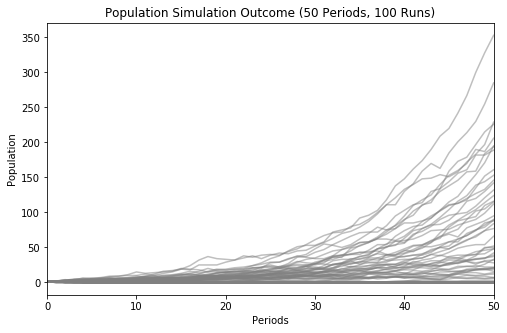

In [15]:
def run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(starting_pop, repro_chance, death_chance)
        for period in range(0, n_periods):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])

# Run the simulation
run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs)

## Conclusion

We can see that the population appears to grow exponentially. We can also see that while a few populations take off by around 30 periods, some take a bit longer and others go completely extinct. You can also see that different outcomes of the simulation runs vary greatly in population size, showing a much wider spread than what was observed in section 1 "